In [31]:
import scanpy as sc
import pandas as pd
import numpy as np
import os 
import glob
from plotnine import *

In [2]:
# Guide assign gene expression matrix
gex_a = sc.read_h5ad('/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/gw-CRISPRa_from_cluster/D1_392i_Rest_lane1/D1_392i_Rest_gex_guide.h5ad')
gex_a.obs.head(n=5)

,library_id,lane_id,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,n_genes,gRNA,guide_id,target_gene,UMI_counts
AAACAAGCAAGTTTCCACAGACCT-1_lane1_D1_392i_Rest,D1_392i_Rest,lane1,1266,7.144407,1755.0,7.470794,17.321937,25.071225,36.467236,56.353276,0.0,0.000000,0.000000,1266,ZC3H12A_A_CRISPRi_2,ZC3H12A_A_CRISPRi_2,ZC3H12A,3.0
AAACAAGCACAACAATACAGACCT-1_lane1_D1_392i_Rest,D1_392i_Rest,lane1,2263,7.724888,3902.0,8.269501,18.682727,24.243977,32.829318,50.076884,17.0,2.890372,0.435674,2263,VAMP8_-_85788707.23-P2_CRISPRi,VAMP8_-_85788707.23-P2_CRISPRi,VAMP8,77.0
AAACAAGCACCGGCAAACAGACCT-1_lane1_D1_392i_Rest,D1_392i_Rest,lane1,2211,7.701652,3916.0,8.273082,20.939734,27.093973,35.750766,52.936670,23.0,3.178054,0.587334,2211,NTC-580,NTC-580,NTC,89.0
AAACAAGCACGTAGGTACAGACCT-1_lane1_D1_392i_Rest,D1_392i_Rest,lane1,1722,7.451822,2666.0,7.888710,17.291823,23.555889,33.383346,54.163541,16.0,2.833213,0.600150,1722,MAPK3_+_30134158.23-P1P2_CRISPRi,MAPK3_+_30134158.23-P1P2_CRISPRi,MAPK3,113.0
AAACAAGCACTAACTCACAGACCT-1_lane1_D1_392i_Rest,D1_392i_Rest,lane1,2149,7.673223,3607.0,8.190908,17.687829,23.703909,32.492376,50.346548,21.0,3.091043,0.582201,2149,NTC-460,NTC-460,NTC,222.0


In [3]:
crispr_a = sc.read_h5ad('/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/gw-CRISPRa_from_cluster/D1_392i_Rest_lane1/D1_392i_Rest_crispr_preprocessed.h5ad')
crispr_a.obs.head(n=5)

,library_id,lane_id,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes
AAACAAGCAAGTTTCCACAGACCT-1_lane1_D1_392i_Rest,D1_392i_Rest,lane1,4,1.609438,6.0,1.945910,100.0,100.0,100.0,100.0
AAACAAGCACAACAATACAGACCT-1_lane1_D1_392i_Rest,D1_392i_Rest,lane1,2,1.098612,78.0,4.369448,100.0,100.0,100.0,100.0
AAACAAGCACCGGCAAACAGACCT-1_lane1_D1_392i_Rest,D1_392i_Rest,lane1,1,0.693147,89.0,4.499810,100.0,100.0,100.0,100.0
AAACAAGCACGTAGGTACAGACCT-1_lane1_D1_392i_Rest,D1_392i_Rest,lane1,3,1.386294,115.0,4.753590,100.0,100.0,100.0,100.0
AAACAAGCACTAACTCACAGACCT-1_lane1_D1_392i_Rest,D1_392i_Rest,lane1,4,1.609438,225.0,5.420535,100.0,100.0,100.0,100.0


In [4]:
# Sanity check on cells
diff = crispr_a.obs.index.difference(gex_a.obs.index)
len(diff)

11

In [5]:
# Checking the guide assignment in cell by type and count
guide_assigned_df = pd.read_csv('/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/gw-CRISPRa_from_cluster/D1_392i_Rest_lane1/guide_assigned.csv')
guide_assigned_df_merge = guide_assigned_df.groupby('cell').agg(
    { 'cell':'size',
      'gRNA': list
    }
)
guide_assigned_df_merge['num_guide_assigned'] = guide_assigned_df_merge['gRNA'].apply(lambda x: len(x))
del guide_assigned_df_merge['cell']

In [6]:
guide_assigned_df_merge.shape

(23277, 2)

In [7]:
gex_df = gex_a.obs.copy()
gex_df.dropna(inplace = True)
gex_df.shape

(23274, 18)

In [8]:
# Sanity check on cells match the gene expression object
identical = guide_assigned_df_merge.index.intersection(gex_df.index)
diff = guide_assigned_df_merge.index.difference(identical)
len(diff)

3

In [9]:
def listing_target_gene(x):
    gene_list = []
    for i in x:
        i = i.split('_')[0]
        gene_list.append(i)
    return gene_list

In [10]:
guide_assigned_df_merge['target_gene'] = guide_assigned_df_merge['gRNA'].apply(lambda x : listing_target_gene(x))
guide_assigned_df_merge

,gRNA,num_guide_assigned,target_gene
cell,,,
AAACAAGCAAGTTTCCACAGACCT-1_lane1_D1_392i_Rest,[ZC3H12A_A_CRISPRi_2],1,[ZC3H12A]
AAACAAGCACAACAATACAGACCT-1_lane1_D1_392i_Rest,[VAMP8_-_85788707.23-P2_CRISPRi],1,[VAMP8]
AAACAAGCACCGGCAAACAGACCT-1_lane1_D1_392i_Rest,[NTC-580],1,[NTC-580]
AAACAAGCACGTAGGTACAGACCT-1_lane1_D1_392i_Rest,[MAPK3_+_30134158.23-P1P2_CRISPRi],1,[MAPK3]
AAACAAGCACTAACTCACAGACCT-1_lane1_D1_392i_Rest,[NTC-460],1,[NTC-460]
...,...,...,...
TTTGTGAGTGCTTCTCACAGACCT-1_lane1_D1_392i_Rest,"[MAPK3_A_CRISPRi_2, MAPK3_A_CRISPRi_3, AP5M1_+...",3,"[MAPK3, MAPK3, AP5M1]"
TTTGTGAGTGTGACCCACAGACCT-1_lane1_D1_392i_Rest,"[BATF_A_CRISPRi_3, PHF14_A_CRISPRi_2]",2,"[BATF, PHF14]"
TTTGTGAGTTAAGGCAACAGACCT-1_lane1_D1_392i_Rest,[ID3_A_CRISPRi_3],1,[ID3]


In [11]:
# Sanity checks for guides assigned 
crispr_var = crispr_a.var.copy()
crispr_var.index

Index(['ACAT1_A_CRISPRi_1', 'ACAT1_A_CRISPRi_2', 'ACAT1_A_CRISPRi_3',
       'ACTB_A_CRISPRi_1', 'ACTB_A_CRISPRi_2', 'ACTB_A_CRISPRi_3',
       'ADORA2A_A_CRISPRi_1', 'ADORA2A_A_CRISPRi_2', 'ADORA2A_A_CRISPRi_3',
       'AKT1_A_CRISPRi_1',
       ...
       'NTC-897', 'NTC-913', 'NTC-916', 'NTC-924', 'NTC-930', 'NTC-931',
       'NTC-941', 'NTC-945', 'NTC-950', 'NTC-966'],
      dtype='object', length=1854)

In [12]:
guide_list = crispr_var.index.difference(guide_assigned_df.gRNA.unique())
len(guide_list)

71

In [13]:
guide_threshold_df = pd.read_csv('/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/gw-CRISPRa_from_cluster/D1_392i_Rest_lane1/guide_threshold.csv')
guide_threshold_df.set_index('gRNA', inplace=True)
guide_threshold_df.shape[0]

1783

In [14]:
crispr_var.shape[0] - guide_threshold_df.shape[0]

71

## Checking mRNA counts by guide assignment

In [15]:
experiment_info = pd.read_csv('/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/gw-CRISPRa_from_cluster/h5ad_raw_files_info.csv')
experiment_info = experiment_info.loc[:, ~experiment_info.columns.str.startswith("Unnamed")]
experiment_info.columns
name = []
for row in experiment_info.itertuples(index=False):
    tmp = []
    for k, v in row._asdict().items():
        t = v+'_'+k
        tmp.append(t)
    name.append(tmp)

In [21]:
def classify_sgrna(df):
    df['sgRNA_type'] = 'single sgRNA'
    # overwrite where gRNA is missing
    df.loc[df['assigned_guide_id'].isna(), 'sgRNA_type'] = 'no sgRNA'
    df.loc[df['assigned_guide_id'].str.startswith('NTC', na=False), 'sgRNA_type'] = 'single NTC sgRNA'
    df.loc[df_guide['assigned_guide_id'].str.startswith('multi', na=False), 'sgRNA_type'] = 'multi sgRNA'
    # Order the rows
    type_order = ['single sgRNA','single NTC sgRNA','multi sgRNA','no sgRNA']
    df['sgRNA_type'] = pd.Categorical(df['sgRNA_type'],categories=type_order,ordered=True)
    # df = df.loc[:, ['lane_id','gRNA', 'assigned_guide_id', 'UMI_counts', 'target_gene','sgRNA_type']]
    return df

In [22]:
df1 = pd.DataFrame()
for i in range(0,len(name)):
    df = pd.DataFrame()
    for j in name[i]:
        path = f'/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/gw-CRISPRa_from_cluster/{j}/'
        guide_pattern = glob.glob(os.path.join(path, "*_gex_guide.h5ad"))[0]
        adata = sc.read_h5ad(os.path.join(path, guide_pattern))
        df_guide = adata.obs
        df_guide = classify_sgrna(df_guide)
        # df_guide['donor'] = j.split('_')[0]
        df_guide['construct'] = '_'.join(j.split('_')[:3])
        # df_guide['condition'] = j.split('_')[2]
        df = pd.concat([df, df_guide])
    df1 = pd.concat([df1, df])

In [23]:
df1

,library_id,lane_id,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,n_genes,gRNA,guide_id,target_gene,UMI_counts,sgRNA_type,construct
AAACAAGCAAGTTTCCACAGACCT-1_lane1_D1_392i_Rest,D1_392i_Rest,lane1,1266,7.144407,1755.0,7.470794,17.321937,25.071225,36.467236,56.353276,0.0,0.000000,0.000000,1266,ZC3H12A_A_CRISPRi_2,ZC3H12A_A_CRISPRi_2,ZC3H12A,3.0,single sgRNA,D1_392i_Rest
AAACAAGCACAACAATACAGACCT-1_lane1_D1_392i_Rest,D1_392i_Rest,lane1,2263,7.724888,3902.0,8.269501,18.682727,24.243977,32.829318,50.076884,17.0,2.890372,0.435674,2263,VAMP8_-_85788707.23-P2_CRISPRi,VAMP8_-_85788707.23-P2_CRISPRi,VAMP8,77.0,single sgRNA,D1_392i_Rest
AAACAAGCACCGGCAAACAGACCT-1_lane1_D1_392i_Rest,D1_392i_Rest,lane1,2211,7.701652,3916.0,8.273082,20.939734,27.093973,35.750766,52.936670,23.0,3.178054,0.587334,2211,NTC-580,NTC-580,NTC,89.0,single NTC sgRNA,D1_392i_Rest
AAACAAGCACGTAGGTACAGACCT-1_lane1_D1_392i_Rest,D1_392i_Rest,lane1,1722,7.451822,2666.0,7.888710,17.291823,23.555889,33.383346,54.163541,16.0,2.833213,0.600150,1722,MAPK3_+_30134158.23-P1P2_CRISPRi,MAPK3_+_30134158.23-P1P2_CRISPRi,MAPK3,113.0,single sgRNA,D1_392i_Rest
AAACAAGCACTAACTCACAGACCT-1_lane1_D1_392i_Rest,D1_392i_Rest,lane1,2149,7.673223,3607.0,8.190908,17.687829,23.703909,32.492376,50.346548,21.0,3.091043,0.582201,2149,NTC-460,NTC-460,NTC,222.0,single NTC sgRNA,D1_392i_Rest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTGAGTTAAGGCAATTCGGTT-1_lane8_D2_408i_Stim,D2_408i_Stim,lane8,4165,8.334712,10301.0,9.240093,10.008737,15.212115,23.133676,38.967091,16.0,2.833213,0.155325,4165,ACAT1_-_107992336.23-P1P2_CRISPRi,ACAT1_-_107992336.23-P1P2_CRISPRi,ACAT1,465.0,single sgRNA,D2_408i_Stim
TTTGTGAGTTAGCTCGATTCGGTT-1_lane8_D2_408i_Stim,D2_408i_Stim,lane8,2064,7.632886,3578.0,8.182838,19.032979,25.572946,34.879821,53.325880,0.0,0.000000,0.000000,2064,MAPK14_A_CRISPRi_3,MAPK14_A_CRISPRi_3,MAPK14,742.0,single sgRNA,D2_408i_Stim
TTTGTGAGTTAGTGGAATTCGGTT-1_lane8_D2_408i_Stim,D2_408i_Stim,lane8,4182,8.338784,9084.0,9.114380,9.103919,13.727433,20.827829,35.843241,38.0,3.663562,0.418318,4182,PIK3R1_A_CRISPRi_1,multi_sgRNA,multi_sgRNA,436.0,multi sgRNA,D2_408i_Stim
TTTGTGAGTTGGATAGATTCGGTT-1_lane8_D2_408i_Stim,D2_408i_Stim,lane8,1466,7.290975,2104.0,7.652071,15.922053,23.336502,33.697719,54.087452,0.0,0.000000,0.000000,1466,CD28_A_CRISPRi_1,CD28_A_CRISPRi_1,CD28,17.0,single sgRNA,D2_408i_Stim


In [24]:
df_plot = (
    df1
    .groupby(['library_id', 'sgRNA_type'], as_index=False)
    .agg(mean_total_counts=('total_counts', 'mean'),
        mean_genes_per_cell = ('n_genes_by_counts', 'mean'),
        mean_guide_umi_counts = ('UMI_counts', 'mean'))
)
df_plot['mean_guide_umi_counts'] = df_plot['mean_guide_umi_counts'].fillna(0)
df_plot

/var/folders/lh/8shkr2ln1lz628fhh9nfhqh00000gp/T/ipykernel_36397/3598587974.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['library_id', 'sgRNA_type'], as_index=False)


,library_id,sgRNA_type,mean_total_counts,mean_genes_per_cell,mean_guide_umi_counts
0,D1_392i_Rest,single sgRNA,3997.471191,2260.312792,165.995682
1,D1_392i_Rest,single NTC sgRNA,3971.745850,2251.373125,189.008575
2,D1_392i_Rest,multi sgRNA,6533.447266,3067.749874,254.059128
3,D1_392i_Rest,no sgRNA,3588.311279,2099.802574,0.000000
4,D1_392i_Stim,single sgRNA,7940.968750,3516.208778,280.960754
...,...,...,...,...,...
59,D2_408i_Rest,no sgRNA,3683.958252,2117.634715,0.000000
60,D2_408i_Stim,single sgRNA,8015.637207,3535.283771,294.896606
61,D2_408i_Stim,single NTC sgRNA,8133.166992,3580.878522,272.122559
62,D2_408i_Stim,multi sgRNA,12319.505859,4325.494585,408.884705


In [26]:
df1_long = df1.melt(
    id_vars=['library_id', 'sgRNA_type'],
    value_vars=['total_counts', 'n_genes_by_counts', 'UMI_counts'],
    var_name='metric',
    value_name='value'
)

# optional: nicer facet names
df1_long['metric'] = df1_long['metric'].map({
    'total_counts': 'Mean mRNA UMIs per cell',
    'n_genes_by_counts': 'Mean genes per cell',
    'UMI_counts': 'Mean guide UMI counts'
})

# ensure numeric + drop missing
df1_long['value'] = pd.to_numeric(df1_long['value'], errors='coerce')
df1_long = df1_long.dropna(subset=['value'])
parts = df1_long['library_id'].str.split('_', expand=True)
df1_long['library_id'] = parts[0] + ' ' + parts[1] + ' ' + parts.iloc[:, -1]

/Users/chandrima.modak/ron_perturb_seq_analysis/gw_CRISPRa_Chandrima/branch_code_env/lib/python3.11/site-packages/plotnine/scales/scale_manual.py:45: PlotnineWarning: The palette of scale_fill_manual can return a maximum of 3 values. 4 were requested from it.
/Users/chandrima.modak/ron_perturb_seq_analysis/gw_CRISPRa_Chandrima/branch_code_env/lib/python3.11/site-packages/plotnine/scales/scale_manual.py:45: PlotnineWarning: The palette of scale_fill_manual can return a maximum of 3 values. 4 were requested from it.


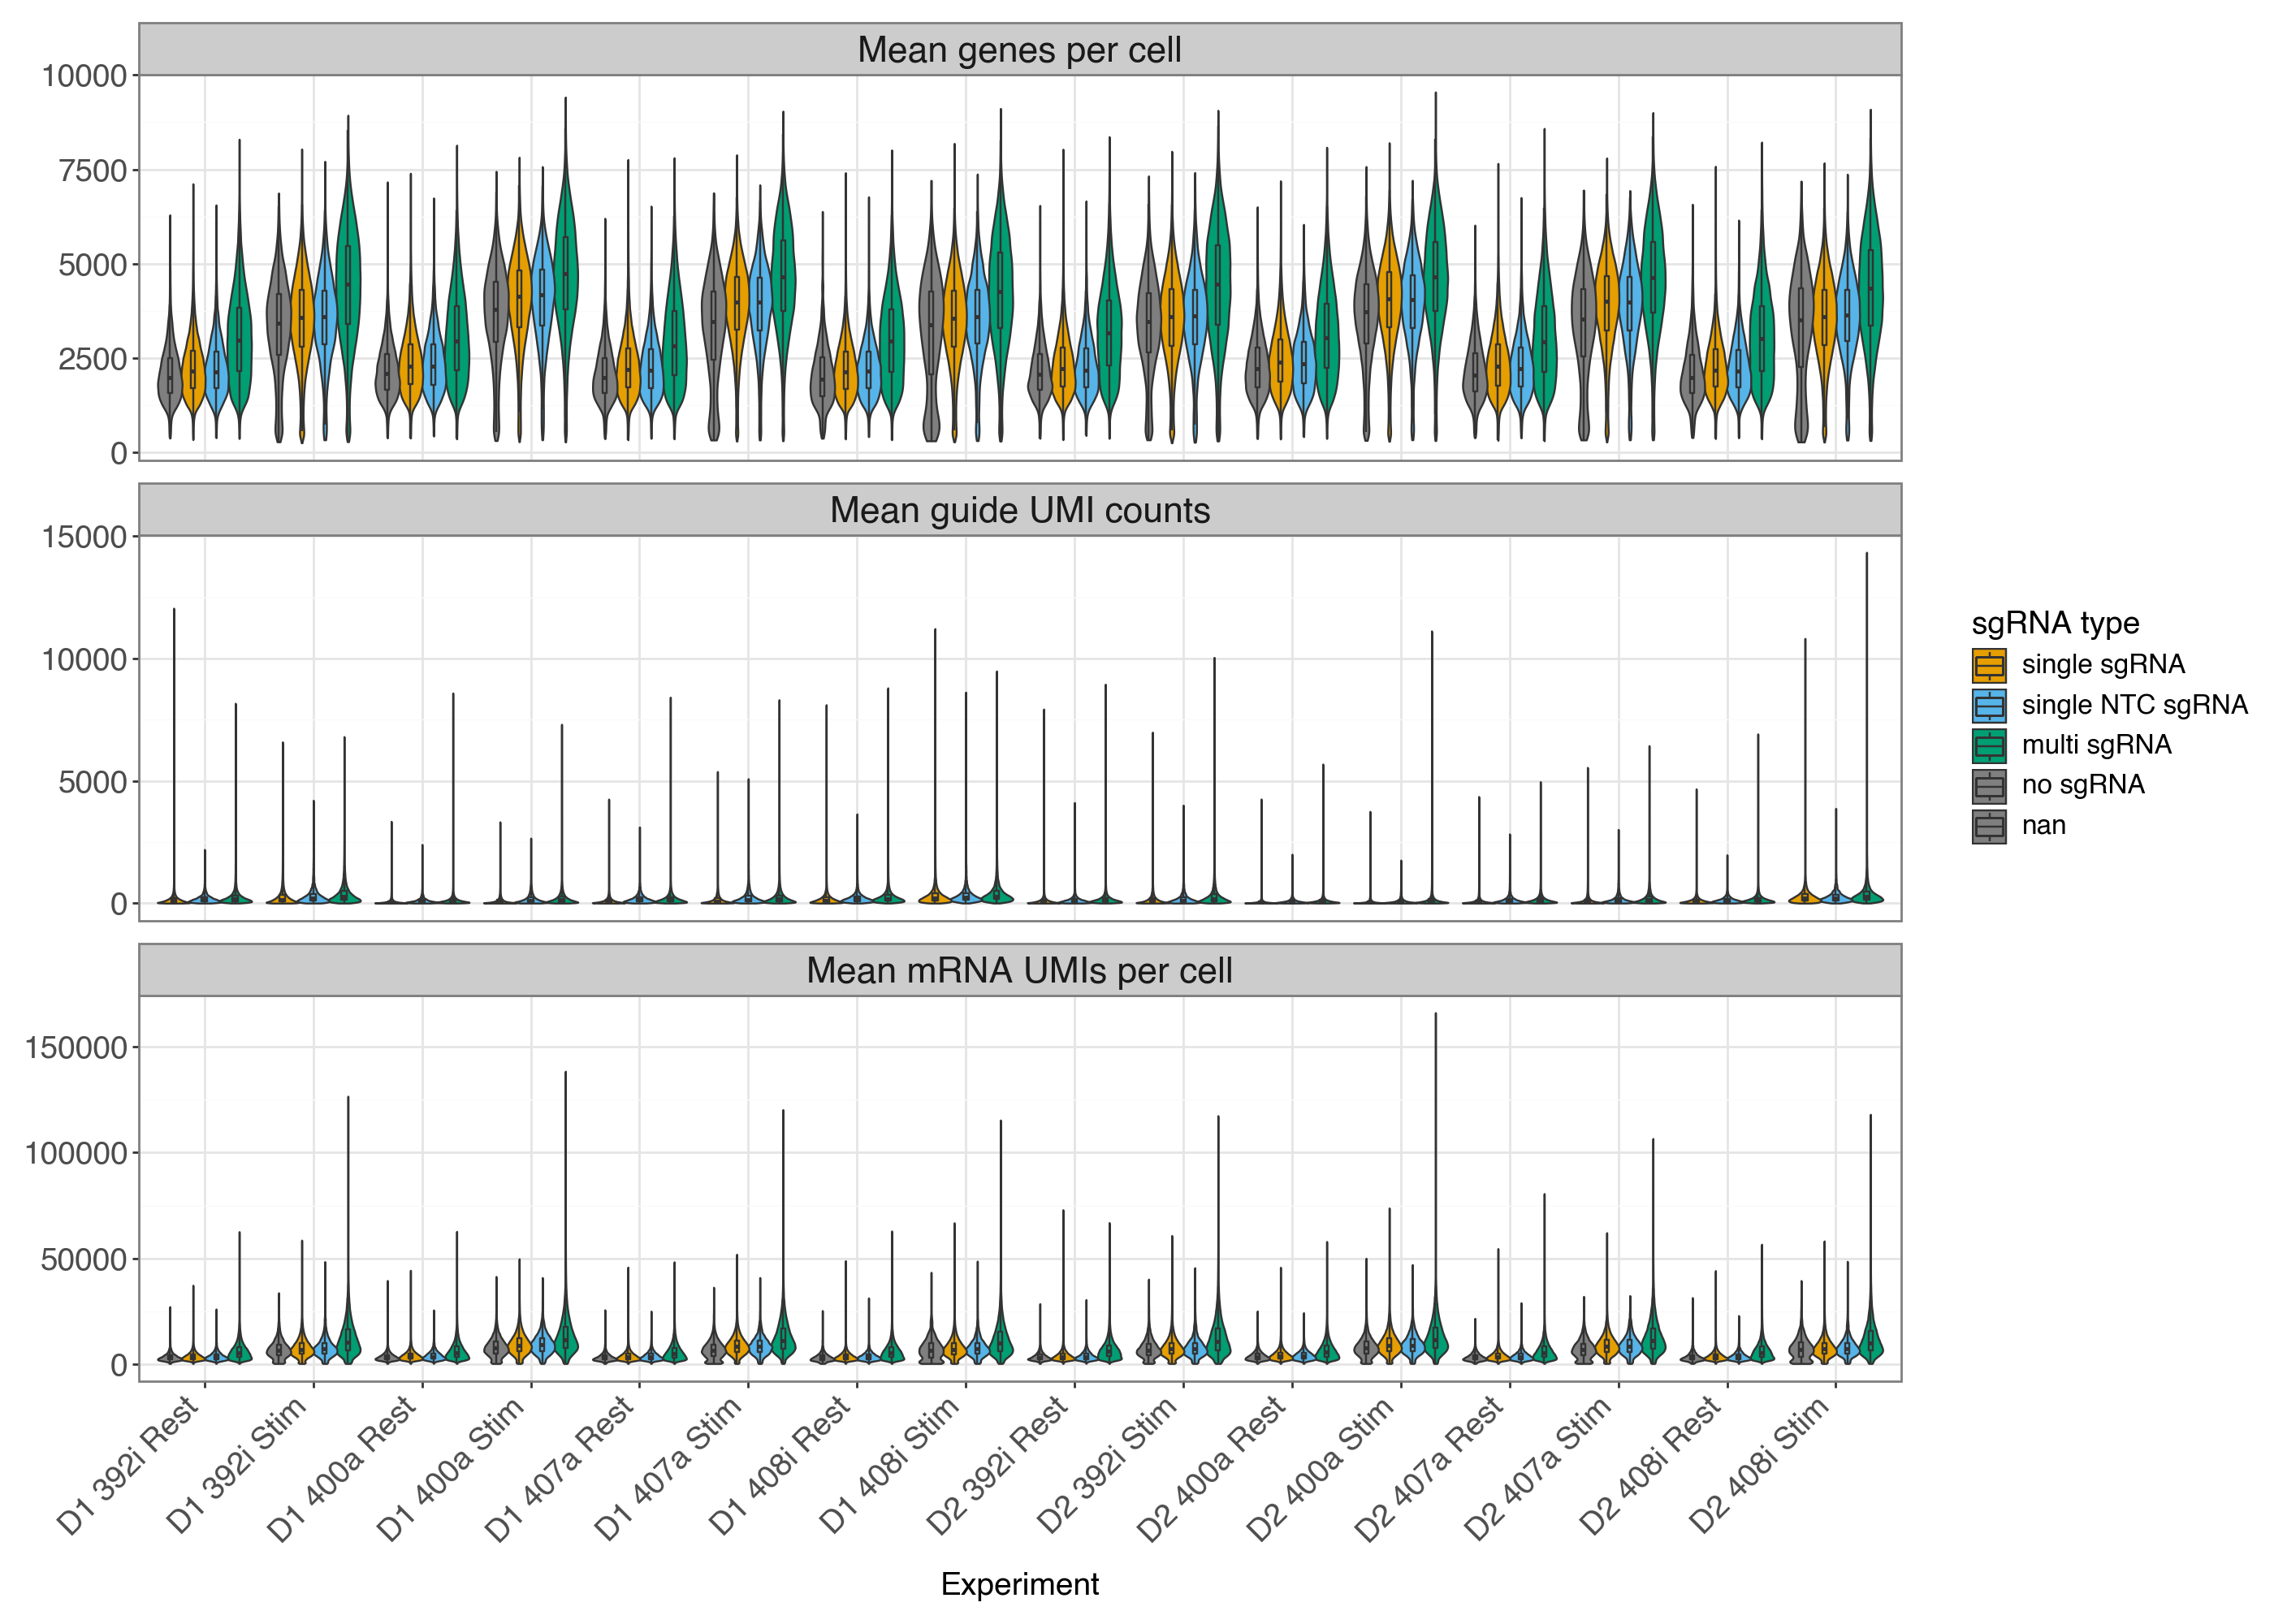

In [34]:
# # Order the rows
type_order = ['single sgRNA','single NTC sgRNA','multi sgRNA', 'no sgRNA']
df1_long['sgRNA_type'] = pd.Categorical(df1_long['sgRNA_type'],categories=type_order,ordered=True)
dodge = position_dodge(width=0.85)

p = (
    ggplot(df1_long, aes(x='library_id', y='value', fill='sgRNA_type'))
    + geom_violin(position=dodge, trim=True, scale='width')
    + geom_boxplot(position=dodge, width=0.15, outlier_alpha=0)
    + facet_wrap('~metric', scales='free_y', nrow=3)
    + scale_fill_manual(values=['#E69F00', '#56B4E9', '#009E73']) 
    + labs(x='Experiment', y='', fill='sgRNA type')
    + theme_bw()
    + theme(
        axis_text_x = element_text(rotation=45, ha='right', size=14),  # x ticks
        axis_text_y = element_text(size=14),                          # y ticks
        axis_title_x = element_text(size=14),                         # axis title
        axis_title_y = element_text(size=14),

        legend_text = element_text(size=12),                          # legend labels
        legend_title = element_text(size=14),                         # legend title

        strip_text = element_text(size=16),                           # facet titles
        figure_size = (14, 10)
    )
)

p